# The Three Theorems of Emanuel Knill

## How One Physicist Shaped the Foundations of Fault-Tolerant Quantum Computing

### What This Notebook Covers

1. **Knill-Laflamme Conditions** (1997) — the necessary and sufficient conditions for quantum error correction
2. **Gottesman-Knill Theorem** (1998) — why Clifford circuits can be efficiently simulated classically
3. **Eastin-Knill Theorem** (2009) — why no error-correcting code admits a universal transversal gate set
4. **The Big Picture** — how these three results together define the landscape of fault-tolerant quantum computing

---

## 1. Emanuel Knill — A Brief Portrait

<img src="../images/emmanuel_knill.png" alt="Emanuel Knill" width="300"/>

**Emanuel (Manny) Knill** is a Fellow of the National Institute of Standards and Technology (NIST) and a Professor Adjoint of Physics at the University of Colorado Boulder. He is also a Fellow of the American Physical Society, elected "for fundamental contributions to our understanding of the control and manipulation of quantum systems."

Working at the intersection of mathematics, computer science, and physics, Knill has been one of the most influential figures in **quantum error correction** and **fault-tolerant quantum computing** since the mid-1990s. His name appears on three landmark theorems that, taken together, define the fundamental boundaries and possibilities of building a reliable quantum computer:

| Theorem | Co-author(s) | Year | Core Message |
|:--------|:-------------|:-----|:-------------|
| Knill-Laflamme Conditions | Raymond Laflamme | 1997 | Necessary and sufficient conditions for quantum error correction |
| Gottesman-Knill Theorem | Daniel Gottesman | 1998 | Clifford circuits are classically simulable in polynomial time |
| Eastin-Knill Theorem | Bryan Eastin | 2009 | No QECC admits a universal transversal gate set |

These three results answer three foundational questions:
- **When** can errors be corrected? (Knill-Laflamme)
- **What** is classically easy to simulate? (Gottesman-Knill)
- **What** is the unavoidable cost of fault tolerance? (Eastin-Knill)

---

## 2. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

from qiskit import QuantumCircuit
from qiskit.quantum_info import (
    Operator, Pauli, SparsePauliOp,
    Statevector, StabilizerState, Clifford,
    random_clifford
)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---

## 3. Theorem I — The Knill-Laflamme Conditions (1997)

### The Problem

Quantum states are fragile. Noise from the environment can corrupt a quantum computation by applying unknown error operators to the qubits. The central question of quantum error correction is: **given a code (a subspace of the full Hilbert space), which errors can it correct?**

### The Theorem

Let $\vert\psi_1\rangle, \vert\psi_2\rangle, \ldots, \vert\psi_l\rangle$ comprise the orthonormal basis of a quantum error-correcting code $\mathcal{C}$. The code can correct all errors in a subset $\mathcal{E}_C$ of the basis error group **if and only if** the following two conditions are satisfied:

#### Condition (a) — Distinguishability (Orthogonality)

$$\langle \psi_i \vert E_a^\dagger E_b \vert \psi_j \rangle = 0 \quad \text{for all } E_a, E_b \in \mathcal{E}_C \text{ and } i \neq j$$

Errors must not make different codewords look the same.

**Analogy — Smudged Letters:** Imagine sending Message A or Message B through a noisy channel. If an error $E$ turns both messages into the *same smudge*, you cannot tell which was sent, so recovery is impossible. Mathematically, this means $\langle \psi_A \vert E^\dagger E \vert \psi_B \rangle \neq 0$ — the two error paths have "overlapped."

A well-designed code ensures error $E$ moves Message A to "Smudge Area 1" and Message B to "Smudge Area 2." As long as these areas are orthogonal (never overlap), you can identify which message was sent and reverse the damage: $\langle \psi_A \vert E^\dagger E \vert \psi_B \rangle = 0$.

#### Condition (b) — Information Hiding (Discretization)

$$\langle \psi_i \vert E_a^\dagger E_b \vert \psi_i \rangle = c_{ab} \quad \text{for all } E_a, E_b \in \mathcal{E}_C \text{ and all } i$$

where $c_{ab}$ depends only on the errors $E_a, E_b$ and is **independent of which codeword** $\vert\psi_i\rangle$ was encoded.

Errors must not leak information about the encoded message to the environment.

**Analogy — The Noisy Safe:** Imagine a safe holding either a Gold Coin ($\vert 0_L\rangle$) or a Silver Coin ($\vert 1_L\rangle$). An error shakes the safe. If Gold produces a "clink" but Silver produces a "thud," the noise reveals what is inside — you have effectively *measured* the state, collapsing any superposition. For the code to work, the shake must sound **exactly the same** regardless of which coin is inside:

$$\langle 0_L \vert E^\dagger E \vert 0_L \rangle = \langle 1_L \vert E^\dagger E \vert 1_L \rangle = c$$

Because $c$ does not depend on the state, you can detect the error without spying on the data.

### Combined (Compact Form)

Both conditions together give the standard compact statement:

$$\langle i_L \vert E_a^\dagger E_b \vert j_L \rangle = C_{ab}\, \delta_{ij} \qquad \text{or equivalently} \qquad P\, E_a^\dagger E_b\, P = C_{ab}\, P$$

### Example: 3-Qubit Bit-Flip Code

The simplest illustration is the 3-qubit repetition code:
- $\vert 0_L\rangle = \vert 000\rangle$, $\quad \vert 1_L\rangle = \vert 111\rangle$
- Correctable errors: $\{I, X_0, X_1, X_2\}$ (identity and single bit-flips)

We verify both conditions by computing $\langle i_L \vert E_a^\dagger E_b \vert j_L\rangle$ for all combinations.

In [3]:
# ---- 3-qubit bit-flip code: define codewords and error set ----
zero_L = Statevector.from_label('000')
one_L  = Statevector.from_label('111')
codewords = {'|0_L>': zero_L, '|1_L>': one_L}

error_labels = ['III', 'XII', 'IXI', 'IIX']
errors = {label: Operator(Pauli(label)) for label in error_labels}

# ---- Verify Knill-Laflamme conditions ----
print("Knill-Laflamme matrix elements: <i_L| Ea+ Eb |j_L>\n")
print(f"{'Ea':<5} {'Eb':<5} {'<0L|..|0L>':>12} {'<1L|..|1L>':>12} {'<0L|..|1L>':>12} {'<1L|..|0L>':>12}  KL?")
print("-" * 75)

kl_satisfied = True
for ea_label, Ea in errors.items():
    for eb_label, Eb in errors.items():
        EaEb = Ea.adjoint().compose(Eb)

        c00 = zero_L.inner(Statevector(np.dot(EaEb.data, zero_L.data)))
        c11 = one_L.inner(Statevector(np.dot(EaEb.data, one_L.data)))
        c01 = zero_L.inner(Statevector(np.dot(EaEb.data, one_L.data)))
        c10 = one_L.inner(Statevector(np.dot(EaEb.data, zero_L.data)))

        diag_ok = np.isclose(c00, c11)
        off_diag_ok = np.isclose(c01, 0) and np.isclose(c10, 0)
        ok = diag_ok and off_diag_ok
        kl_satisfied &= ok

        check = "pass" if ok else "FAIL"
        print(f"{ea_label:<5} {eb_label:<5} {c00.real:>12.4f} {c11.real:>12.4f} {c01.real:>12.4f} {c10.real:>12.4f}  {check}")

print(f"\nKnill-Laflamme conditions satisfied: {kl_satisfied}")

Knill-Laflamme matrix elements: <i_L| Ea+ Eb |j_L>

Ea    Eb      <0L|..|0L>   <1L|..|1L>   <0L|..|1L>   <1L|..|0L>  KL?
---------------------------------------------------------------------------
III   III         1.0000       1.0000       0.0000       0.0000  pass
III   XII         0.0000       0.0000       0.0000       0.0000  pass
III   IXI         0.0000       0.0000       0.0000       0.0000  pass
III   IIX         0.0000       0.0000       0.0000       0.0000  pass
XII   III         0.0000       0.0000       0.0000       0.0000  pass
XII   XII         1.0000       1.0000       0.0000       0.0000  pass
XII   IXI         0.0000       0.0000       0.0000       0.0000  pass
XII   IIX         0.0000       0.0000       0.0000       0.0000  pass
IXI   III         0.0000       0.0000       0.0000       0.0000  pass
IXI   XII         0.0000       0.0000       0.0000       0.0000  pass
IXI   IXI         1.0000       1.0000       0.0000       0.0000  pass
IXI   IIX         0.0000       0.

The diagonal elements $\langle 0_L \vert E_a^\dagger E_b \vert 0_L\rangle$ and $\langle 1_L \vert E_a^\dagger E_b \vert 1_L\rangle$ are equal (same $C_{ab}$), and the off-diagonal elements are zero. The Knill-Laflamme conditions hold, confirming the 3-qubit code can correct any single bit-flip.

Let us also visualize the $C_{ab}$ matrix and the encoding circuit.

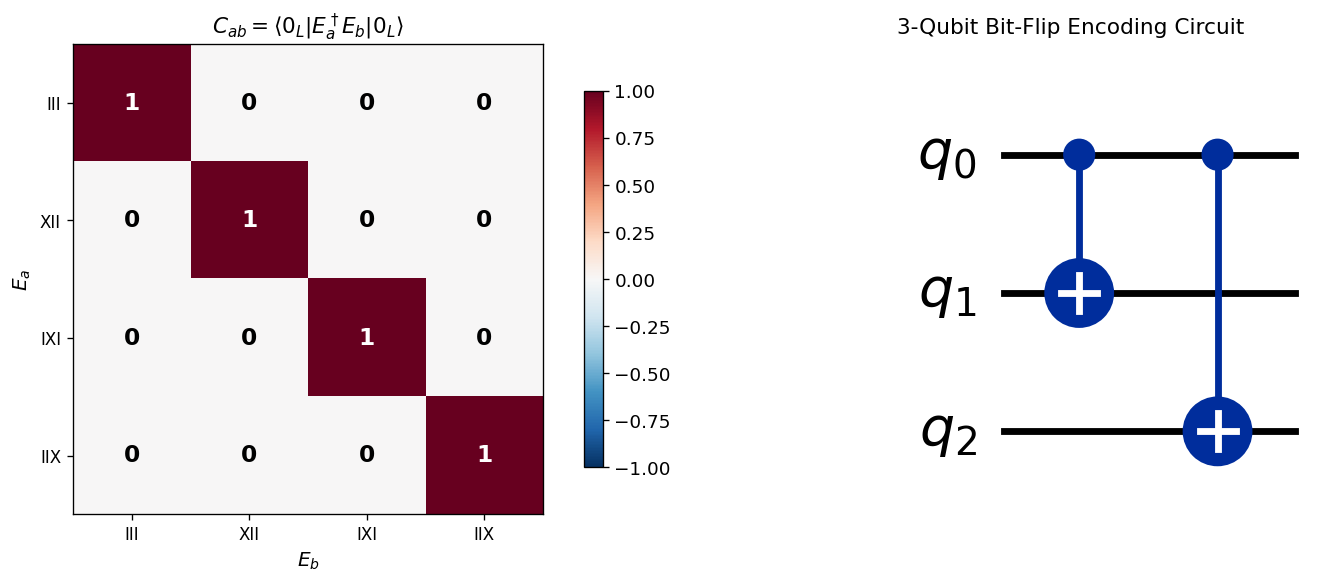

In [4]:
# ---- Build and display the C_ab matrix ----
n_errors = len(error_labels)
C_matrix = np.zeros((n_errors, n_errors), dtype=complex)

for i, (ea_label, Ea) in enumerate(errors.items()):
    for j, (eb_label, Eb) in enumerate(errors.items()):
        EaEb = Ea.adjoint().compose(Eb)
        C_matrix[i, j] = zero_L.inner(Statevector(np.dot(EaEb.data, zero_L.data)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- C_ab heatmap ----
ax = axes[0]
im = ax.imshow(C_matrix.real, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
ax.set_xticks(range(n_errors))
ax.set_xticklabels(error_labels, fontsize=10)
ax.set_yticks(range(n_errors))
ax.set_yticklabels(error_labels, fontsize=10)
ax.set_xlabel(r'$E_b$', fontsize=12)
ax.set_ylabel(r'$E_a$', fontsize=12)
ax.set_title(r'$C_{ab} = \langle 0_L | E_a^\dagger E_b | 0_L \rangle$', fontsize=13)
for i in range(n_errors):
    for j in range(n_errors):
        ax.text(j, i, f'{C_matrix[i,j].real:.0f}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if abs(C_matrix[i,j].real) > 0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)

# ---- 3-qubit encoding circuit ----
ax = axes[1]
qc_enc = QuantumCircuit(3)
qc_enc.cx(0, 1)
qc_enc.cx(0, 2)
qc_enc.draw('mpl', style='iqp', ax=ax)
ax.set_title('3-Qubit Bit-Flip Encoding Circuit', fontsize=13)

plt.tight_layout()
plt.show()

---

## 4. Theorem II — The Gottesman-Knill Theorem (1998)

### The Problem

A general $n$-qubit quantum state requires $2^n$ complex amplitudes to describe. Simulating quantum circuits on a classical computer therefore appears to require exponential resources. But is this always the case?

### The Theorem

The Gottesman-Knill theorem states that a quantum circuit can be **efficiently simulated on a classical computer** (in polynomial time) if it consists only of:

1. Preparation of qubits in computational basis states $\vert 0\rangle$ or $\vert 1\rangle$
2. **Clifford gates**: $H$ (Hadamard), $S$ (phase), and $\text{CNOT}$
3. Measurements in the computational basis
4. Classical feed-forward (conditioning operations on measurement outcomes)

The simulation works in the **Heisenberg picture**: instead of tracking $2^n$ amplitudes, one tracks the evolution of $n$ stabilizer generators (Pauli operators). Each gate updates the generators in $O(n)$ time, giving an overall $O(n^2)$ simulation for $n$ gates.

### Why It Matters

- **Entanglement is not enough**: Clifford circuits can create maximally entangled states (Bell states, GHZ states), yet they are classically simulable.
- **Quantum advantage requires non-Clifford resources**: specifically, gates like the $T$ gate (or equivalently, **magic states**).
- This theorem motivates the concept of **magic** (nonstabilizerness) as the true computational resource for quantum speedup.

### Demonstration: Clifford Simulation with Qiskit

We build a 50-qubit Clifford circuit — far beyond what statevector simulation can handle ($2^{50} \approx 10^{15}$ amplitudes) — and show that `StabilizerState` handles it instantly.

In [6]:
import time

# ---- 50-qubit Clifford circuit: classically simulable! ----
n_qubits = 50
qc_cliff = QuantumCircuit(n_qubits)

for i in range(n_qubits):
    qc_cliff.h(i)
for i in range(n_qubits - 1):
    qc_cliff.cx(i, i + 1)
for i in range(n_qubits):
    qc_cliff.s(i)
for i in range(0, n_qubits - 1, 2):
    qc_cliff.cx(i + 1, i)

print(f"Circuit: {n_qubits} qubits, {qc_cliff.size()} gates (all Clifford)")
print(f"Statevector would need 2^{n_qubits} = {2**n_qubits:.2e} amplitudes\n")

t0 = time.time()
stab = StabilizerState(qc_cliff)
t1 = time.time()

print(f"StabilizerState created in {t1 - t0:.4f} seconds")
print(f"Memory: just {n_qubits} stabilizer generators (each {n_qubits} Paulis)")
print(f"\nFirst 5 stabilizer generators:")
for gen in stab.clifford.to_labels()[:5]:
    print(f"  {gen}")

Circuit: 50 qubits, 174 gates (all Clifford)
Statevector would need 2^50 = 1.13e+15 amplitudes

StabilizerState created in 0.0050 seconds
Memory: just 50 stabilizer generators (each 50 Paulis)

First 5 stabilizer generators:
  +IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ
  +IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ
  +IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZI
  +IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZII
  +IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZIII


### The Clifford Boundary: What Breaks Classical Simulation?

Adding a single non-Clifford gate (like the $T$ gate) to a Clifford circuit takes us outside the stabilizer formalism. Let us demonstrate this contrast on a small scale.

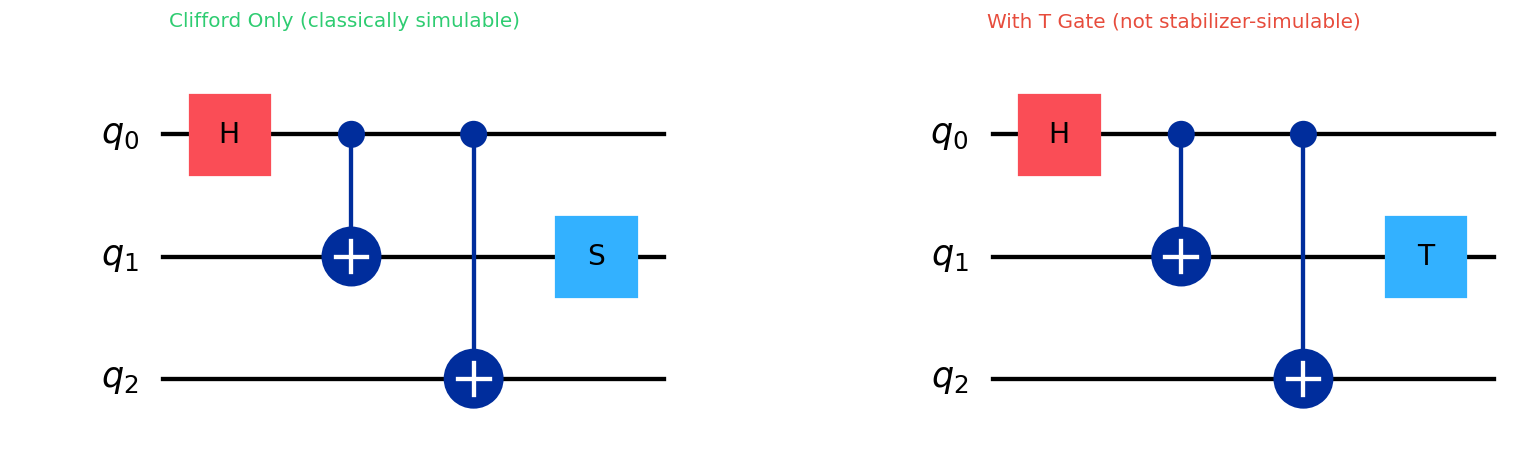

Clifford circuit → StabilizerState works:
  Success! 6 stabilizer generators

Non-Clifford circuit → StabilizerState fails:
  Expected failure: QiskitError: 'Cannot update Clifford with non-Clifford gate t'


In [7]:
# ---- Clifford vs non-Clifford: stabilizer check ----
qc_clifford = QuantumCircuit(3)
qc_clifford.h(0)
qc_clifford.cx(0, 1)
qc_clifford.cx(0, 2)
qc_clifford.s(1)

qc_non_clifford = QuantumCircuit(3)
qc_non_clifford.h(0)
qc_non_clifford.cx(0, 1)
qc_non_clifford.cx(0, 2)
qc_non_clifford.t(1)  # <-- T gate breaks stabilizer formalism

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

qc_clifford.draw('mpl', style='iqp', ax=axes[0])
axes[0].set_title('Clifford Only (classically simulable)', fontsize=12, color='#2ECC71')

qc_non_clifford.draw('mpl', style='iqp', ax=axes[1])
axes[1].set_title('With T Gate (not stabilizer-simulable)', fontsize=12, color='#E74C3C')

plt.tight_layout()
plt.show()

print("Clifford circuit → StabilizerState works:")
try:
    s = StabilizerState(qc_clifford)
    print(f"  Success! {len(s.clifford.to_labels())} stabilizer generators\n")
except Exception as e:
    print(f"  Failed: {e}\n")

print("Non-Clifford circuit → StabilizerState fails:")
try:
    s = StabilizerState(qc_non_clifford)
    print(f"  Success! (unexpected)")
except Exception as e:
    print(f"  Expected failure: {type(e).__name__}: {e}")

---

## 5. Theorem III — The Eastin-Knill Theorem (2009)

### The Problem

**Transversal gates** are the gold standard for fault tolerance: a transversal gate applies independent operations to each physical qubit in a code block, so errors cannot spread within a block. Naturally, we would love to implement *all* gates transversally.

### The Theorem

The Eastin-Knill theorem proves this is **impossible**:

> No quantum error-detecting code can implement a **universal** gate set using only transversal gates.

More precisely, for any code that can detect at least one error on any single physical subsystem, the group of transversal logical gates forms a **finite subgroup** of the unitary group — and a finite group can never be universal (which requires a dense subgroup).

### The Tension

This creates a fundamental trade-off in fault-tolerant quantum computing:

| Property | Transversal Gates | Universal Gate Set |
|:---------|:-----------------|:-------------------|
| Fault-tolerant by construction | Yes | Need additional techniques |
| Prevents error propagation | Yes | Not guaranteed |
| Sufficient for universal QC | **No** (Eastin-Knill) | Yes, by definition |

### Workarounds

Since we cannot have both transversality and universality, the field has developed several workarounds:

1. **Magic state distillation + gate teleportation** (most common): implement Clifford gates transversally, then "inject" non-Clifford operations via pre-prepared magic states
2. **Code switching**: move between different codes that each support different transversal gates
3. **Gauge fixing**: use subsystem codes where gauge freedom enables additional transversal gates

### Demonstration: Transversal Gates of the Steane Code

The $[\![7,1,3]\!]$ **Steane code** (a CSS code) supports transversal $H$, $S$, and $\text{CNOT}$ — the full Clifford group — but *not* a transversal $T$ gate. This is a direct consequence of Eastin-Knill: the Clifford group is a finite group, not universal.

In [8]:
# ---- Steane [[7,1,3]] code: stabilizer generators ----
steane_generators = [
    'IIIXXXX',
    'IXXIIXX',
    'XIXIXIX',
    'IIIZZZZ',
    'IZZIIZZ',
    'ZIZIZIZ',
]

logical_X = Pauli('XXXXXXX')
logical_Z = Pauli('ZZZZZZZ')

print("Steane [[7,1,3]] Code")
print("=" * 40)
print("\nStabilizer generators:")
for i, g in enumerate(steane_generators):
    print(f"  g{i+1} = {g}")
print(f"\nLogical X_L = {logical_X.to_label()}")
print(f"Logical Z_L = {logical_Z.to_label()}")

# ---- Verify transversal H maps stabilizers correctly ----
print("\n" + "=" * 40)
print("Transversal H: apply H to every physical qubit")
print("H maps X↔Z, so X-type stabilizers ↔ Z-type stabilizers\n")

for g_str in steane_generators:
    pauli = Pauli(g_str)
    h_mapped = ''.join(
        'X' if c == 'Z' else 'Z' if c == 'X' else 'I'
        for c in g_str
    )
    in_stab = h_mapped in steane_generators
    sign = "  (in stabilizer group)" if in_stab else "  (NOT in stabilizer group!)"
    print(f"  {g_str}  →  {h_mapped}{sign}")

print("\nTransversal H preserves the code space (maps stabilizers to stabilizers).")
print("Transversal S also preserves the code space (maps X→Y, Z→Z).")
print("Transversal CNOT between two code blocks preserves the code space.")
print("\nBut transversal T does NOT preserve the code space → Eastin-Knill in action!")

Steane [[7,1,3]] Code

Stabilizer generators:
  g1 = IIIXXXX
  g2 = IXXIIXX
  g3 = XIXIXIX
  g4 = IIIZZZZ
  g5 = IZZIIZZ
  g6 = ZIZIZIZ

Logical X_L = XXXXXXX
Logical Z_L = ZZZZZZZ

Transversal H: apply H to every physical qubit
H maps X↔Z, so X-type stabilizers ↔ Z-type stabilizers

  IIIXXXX  →  IIIZZZZ  (in stabilizer group)
  IXXIIXX  →  IZZIIZZ  (in stabilizer group)
  XIXIXIX  →  ZIZIZIZ  (in stabilizer group)
  IIIZZZZ  →  IIIXXXX  (in stabilizer group)
  IZZIIZZ  →  IXXIIXX  (in stabilizer group)
  ZIZIZIZ  →  XIXIXIX  (in stabilizer group)

Transversal H preserves the code space (maps stabilizers to stabilizers).
Transversal S also preserves the code space (maps X→Y, Z→Z).
Transversal CNOT between two code blocks preserves the code space.

But transversal T does NOT preserve the code space → Eastin-Knill in action!


The Steane code exemplifies the Eastin-Knill theorem perfectly: it supports a transversal Clifford group, but cannot support the $T$ gate transversally. To achieve universality, we must supplement transversal Cliffords with magic state injection — a more complex, non-transversal protocol.

---

## 6. The Big Picture — Three Theorems, One Landscape

Knill's three theorems are not isolated results. Together, they form a coherent narrative about the **possibilities and limitations** of fault-tolerant quantum computing:

```
                      ┌─────────────────────────┐
                      │  Can we correct errors? │
                      │    (Knill-Laflamme)     │
                      └────────────┬────────────┘
                                   │ YES, if conditions met
                                   ▼
                      ┌─────────────────────────┐
                      │  What can we simulate   │
                      │  classically?           │
                      │    (Gottesman-Knill)    │
                      └────────────┬────────────┘
                                   │ Clifford circuits → classical
                                   │ Need non-Clifford for advantage
                                   ▼
                      ┌─────────────────────────┐
                      │  Can we do everything   │
                      │  fault-tolerantly?      │
                      │    (Eastin-Knill)       │
                      └────────────┬────────────┘
                                   │ NOT with transversal gates alone
                                   │ → Magic state distillation
                                   ▼
                      ┌─────────────────────────┐
                      │  Fault-Tolerant QC =    │
                      │  QEC + Clifford gates   │
                      │  + Magic states         │
                      └─────────────────────────┘
```

The path to a useful quantum computer requires:
1. **Error-correcting codes** that satisfy the Knill-Laflamme conditions
2. **Clifford gates** implemented transversally (cheap but classically simulable)
3. **Magic states** to supply the non-Clifford resources that Gottesman-Knill tells us we need and Eastin-Knill tells us we cannot get transversally

---

## Key Takeaways

1. **Knill-Laflamme conditions** give a clean, checkable criterion ($P E_a^\dagger E_b P = C_{ab} P$) for whether a quantum code can correct a given error set — they are the foundation on which all of quantum error correction rests.

2. **Gottesman-Knill theorem** reveals that entanglement alone does not give quantum advantage — Clifford circuits (H, S, CNOT) are classically simulable via the stabilizer formalism, even for thousands of qubits.

3. **Eastin-Knill theorem** imposes an unavoidable cost: no error-correcting code can implement all gates transversally, forcing the use of resource-intensive techniques like magic state distillation for universality.

4. The three theorems together define the **architecture of fault-tolerant quantum computing**: use QEC codes (Knill-Laflamme), implement the "easy" Clifford part transversally (Gottesman-Knill tells us this is classically simulable anyway), and pay the overhead for non-Clifford gates via magic states (Eastin-Knill says there is no shortcut).

5. Emanuel Knill's contributions span the entire stack — from the mathematical foundations of error correction to the computational complexity of simulation to the engineering constraints of fault tolerance — making him one of the most influential figures in quantum computing.

---

## References

- [Knill, E. & Laflamme, R. (1997). *Theory of Quantum Error-Correcting Codes*](https://arxiv.org/abs/quant-ph/9604034)
- [Gottesman, D. (1998). *The Heisenberg Representation of Quantum Computers*](https://arxiv.org/abs/quant-ph/9807006)
- [Eastin, B. & Knill, E. (2009). *Restrictions on Transversal Encoded Quantum Gate Sets*](https://arxiv.org/abs/0811.4262)
- [Qiskit Documentation: StabilizerState](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.StabilizerState)
- [Qiskit Documentation: Clifford](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.Clifford)

In [10]:
import sys, qiskit, matplotlib

print("--- Disclosure ---")
print("AI tool used - Claude Code (Claude Opus 4.6, Anthropic)")
print("Library versions:")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  Qiskit     : {qiskit.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Matplotlib : {matplotlib.__version__}")

--- Disclosure ---
AI tool used - Claude Code (Claude Opus 4.6, Anthropic)
Library versions:
  Python     : 3.11.5
  Qiskit     : 2.3.0
  NumPy      : 2.3.3
  Matplotlib : 3.10.7
